# 두 피처 Ridge — 로그 수명을 학습하고 사이클 수명으로 평가하기

**입력 피처는 기존의 두 개를 그대로 사용합니다. 이번 모델의 학습 정답은 `log10(cycle_life)`입니다.**

| 역할 | 값 |
|---|---|
| 피처 1 | `log10_delta_q_var`: 실제 100·10사이클 방전곡선 차이의 로그 분산 |
| 피처 2 | `SOC_switch_pct`: 충전 정책에 적힌 SOC 전환점(%) |
| 학습 정답 | `log10(cycle_life)` |
| 최종 예측 | 로그 예측값을 `10 ** 값`으로 복원한 수명(사이클) |
| 주요 평가 | 복원한 수명의 MAPE(%), 낮을수록 좋음 |

원본 MAT에서 직접 준비하므로 **EDA나 기존 모델링 노트북을 먼저 실행하지 않아도 됩니다.**
`Restart Kernel → Run All` 또는 위에서 아래로 한 셀씩 실행하세요. 각 코드 바로 아래에 설명이 있습니다.

**결과를 먼저 찾으려면:** 「8. Train / Valid / Test / GAP 결과」의 6행 표를 봅니다.
「9. 원수명 Ridge와 비교」에서는 같은 두 피처로 로그 변환 전후를 비교합니다.

원논문은 피처의 선형 결합으로 로그 수명을 예측합니다. 여기서는 그 타깃 변환을 도입하되,
요청한 **Ridge와 두 피처**, 기존의 **B1 학습·B2 테스트**를 유지합니다.
원논문과 모델·데이터 분할·정제 조건이 모두 같은 재현 실험은 아닙니다.
[원논문, p.385의 Model development](https://petermattia.com/papers/Severson%2C%20Attia%20et%20al.%20-%202019%20-%20Data-driven%20prediction%20of%20battery%20cycle%20life%20before%20capacity%20degradation.pdf#page=3)

## 1. 실행 준비와 로그 변환 이해

In [1]:
from pathlib import Path
import hashlib
import json
import re
import sys

import h5py
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.special import exp10
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (mean_absolute_error, mean_absolute_percentage_error,
                             mean_squared_error, r2_score)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

FEATURES = ['log10_delta_q_var', 'SOC_switch_pct']
TARGET = 'cycle_life'
SEED = 20261002
ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]
PAPER_TARGET_MAPE = 9.1
SAVE_OUTPUTS = False
ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
             if (p / 'data/2017-05-12_batchdata_updated_struct_errorcorrect.mat').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('원본 data/ 폴더가 있는 archive 프로젝트 내부에서 실행하세요.')
BATCH_FILES = {
    'B1': ROOT / 'data/2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    'B2': ROOT / 'data/2018-02-20_batchdata_updated_struct_errorcorrect.mat',
}
missing_files = [str(p) for p in BATCH_FILES.values() if not p.is_file()]
if missing_files:
    raise FileNotFoundError('원본 MAT 파일 누락: ' + ', '.join(missing_files))
OUT = ROOT / 'Modeling/results/ridge_loglife_2features'
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'font.size': 10, 'figure.figsize': (11, 4.5)})
print('Python:', sys.executable)
print('피처:', FEATURES, '/ 별도 파일 저장:', SAVE_OUTPUTS)
display(pd.DataFrame([{'batch': b, 'file': p.name} for b, p in BATCH_FILES.items()]))

Matplotlib is building the font cache; this may take a moment.


Python: /Users/suyeong/Downloads/archive/.venv/bin/python
피처: ['log10_delta_q_var', 'SOC_switch_pct'] / 별도 파일 저장: False


,batch,file
0,B1,2017-05-12_batchdata_updated_struct_errorcorre...
1,B2,2018-02-20_batchdata_updated_struct_errorcorre...


**코드 설명:** 두 피처와 분할 시드, Ridge의 `alpha` 후보를 고정합니다.
`exp10(z)`는 `10 ** z`와 같은 복원 함수입니다. B1·B2의 원본 MAT만 사용하고 B3는 읽지 않습니다.
`SAVE_OUTPUTS=False`가 기본값이므로 결과는 노트북에 표시하며 별도 결과 폴더를 만들지 않습니다.

In [2]:
log_example = pd.DataFrame({'actual_cycles': [400.0, 800.0, 1600.0]})
log_example['log10_life'] = np.log10(log_example['actual_cycles'])
log_example['restored_cycles'] = exp10(log_example['log10_life'])
display(log_example.round(4))
print('400 → 800과 800 → 1600의 로그 차이:',
      np.diff(log_example['log10_life'].to_numpy()))

,actual_cycles,log10_life,restored_cycles
0,400.0,2.6021,400.0
1,800.0,2.9031,800.0
2,1600.0,3.2041,1600.0


400 → 800과 800 → 1600의 로그 차이: [0.30103 0.30103]


**코드 설명:** `np.log10`으로 수명을 바꾸고, `exp10`으로 다시 사이클 단위로 돌려봅니다.
400→800과 800→1,600은 모두 두 배이므로 로그 차이가 같습니다. 로그 학습에서는 이런
**비율 차이**를 다루기 쉬워집니다. 다만 Ridge는 로그 공간의 제곱 오차를 학습하므로 MAPE를
직접 최소화하는 모델은 아닙니다. 이후 `alpha` 선택과 최종 평가는 복원한 수명의 MAPE로 합니다.

**피처 로그와 타깃 로그는 별개입니다.** 이미 로그인 첫 번째 피처는 그대로 두고,
이번에는 정답 수명에도 로그를 적용합니다. 수명은 반드시 양수여야 합니다.

## 2. 원본 MAT에서 두 피처와 수명 준비

In [3]:
def raw_delta_q_feature(file, batch, cell_id):
    summary = file[np.asarray(batch["summary"]).reshape(-1)[cell_id]]
    cycles = file[np.asarray(batch["cycles"]).reshape(-1)[cell_id]]
    actual = np.asarray(summary["cycle"], dtype=float).reshape(-1)
    assert np.isfinite(actual).all() and np.equal(actual, np.floor(actual)).all(), "invalid_cycle_numbers"
    assert np.all(np.diff(actual) > 0), "cycle_numbers_not_unique_and_increasing"
    assert len(actual) == int(np.prod(cycles["Qdlin"].shape)), "summary_Qdlin_cycle_mismatch"
    positions = [np.flatnonzero(actual == cycle) for cycle in (10, 100)]
    assert all(len(position) == 1 for position in positions), "actual_cycle_10_or_100_missing"
    refs = np.asarray(cycles["Qdlin"]).reshape(-1)
    q10, q100 = [np.asarray(file[refs[int(position[0])]], dtype=float).reshape(-1)
                 for position in positions]
    voltage_ref = np.asarray(batch["Vdlin"]).reshape(-1)[cell_id]
    voltage = np.asarray(file[voltage_ref], dtype=float).reshape(-1)
    assert len(q10) == len(q100) == len(voltage) == 1000, "grid_length_not_1000"
    assert all(np.isfinite(vector).all() for vector in [q10, q100, voltage]), "nonfinite_curve_or_grid"
    assert np.all(np.diff(voltage) > 0) or np.all(np.diff(voltage) < 0), "voltage_not_monotonic"
    assert np.ptp(q10) > 0 and np.ptp(q100) > 0, "placeholder_discharge_curve"
    variance = float(np.var(q100 - q10, ddof=0))
    assert np.isfinite(variance) and variance > 0, "invalid_variance"
    return float(np.log10(variance))

POLICY_PATTERN = re.compile(
    r"^\s*(?P<C1>\d+(?:\.\d+)?)\s*C\s*\(\s*(?P<SOC>\d+(?:\.\d+)?)\s*%\s*\)\s*-\s*"
    r"(?P<C2>\d+(?:\.\d+)?)\s*C(?P<suffix>.*)$", re.IGNORECASE)

**코드 설명:** 실제 사이클 번호가 10·100인 위치를 찾고, 같은 전압 축의 `Qdlin`을 읽습니다.
`Q100(V) − Q10(V)`의 1,000개 값에 대해 `ddof=0` 분산을 계산한 뒤 `log10`을 취합니다.
사이클 번호·곡선 길이·전압 축·유한값을 검사합니다. 이 검사를 통과하지 못하면 다음 함수가
상태를 기록합니다. 분산이 1보다 작으면 로그 피처는 음수이며, 이 음수는 정상입니다.

In [4]:
def load_raw_inputs():
    rows = []
    for batch_id, path in BATCH_FILES.items():
        with h5py.File(path, "r") as file:
            batch = file["batch"]
            refs = {name: np.asarray(batch[name]).reshape(-1)
                    for name in ["cycle_life", "policy_readable", "summary", "cycles", "Vdlin"]}
            assert len({len(values) for values in refs.values()}) == 1, "cell_reference_count_mismatch"
            for cell_id in range(len(refs["summary"])):
                life = float(np.asarray(file[refs["cycle_life"][cell_id]]).reshape(-1)[0])
                policy = "".join(chr(int(value)) for value in np.asarray(file[refs["policy_readable"][cell_id]]).reshape(-1))
                row = {"cell_uid": f"{batch_id}_{cell_id}", "batch_id": batch_id,
                       "cycle_life": life if np.isfinite(life) and life > 0 else np.nan,
                       "charging_policy": policy, "log10_delta_q_var": np.nan, "dq_status": "not_read",
                       "SOC_switch_pct": np.nan, "C1": np.nan, "C2": np.nan, "policy_suffix": ""}
                match = POLICY_PATTERN.fullmatch(policy)
                if match:
                    row["policy_suffix"] = match["suffix"].strip()
                    c1, soc, c2 = float(match["C1"]), float(match["SOC"]), float(match["C2"])
                    if c1 > 0 and c2 > 0 and 0 < soc <= 80:
                        row.update(C1=c1, SOC_switch_pct=soc, C2=c2)
                try:
                    row.update(log10_delta_q_var=raw_delta_q_feature(file, batch, cell_id), dq_status="ok")
                except (AssertionError, KeyError, IndexError, ValueError, TypeError, OSError) as error:
                    row["dq_status"] = str(error)
                rows.append(row)
    return pd.DataFrame(rows)

**코드 설명:** 배터리 셀 하나를 표의 한 행으로 만듭니다. 파일에 저장된 `cycle_life`를 읽고,
충전 정책 문자열에서 SOC·C1·C2를 추출합니다. **모델 입력은 ΔQ 로그 분산과 SOC 두 개뿐**입니다.
C1·C2·접미사는 같은 정책을 그룹으로 묶는 데 사용합니다.
MAT는 읽기 모드로 열며, ΔQ 추출 실패는 `dq_status`에 남깁니다.

In [5]:
data = load_raw_inputs()
assert data['cell_uid'].notna().all() and data['cell_uid'].is_unique
print('입력 방식: 원본 MAT 직접 추출')
display(data[['cell_uid', 'batch_id', *FEATURES, TARGET, 'dq_status']].head())

입력 방식: 원본 MAT 직접 추출


,cell_uid,batch_id,log10_delta_q_var,SOC_switch_pct,cycle_life,dq_status
0,B1_0,B1,-5.014861,80.0,1190.0,ok
1,B1_1,B1,-5.013960,80.0,1179.0,ok
2,B1_2,B1,-4.737000,80.0,1177.0,ok
3,B1_3,B1,-4.442613,80.0,1226.0,ok
4,B1_4,B1,-4.647744,80.0,1227.0,ok


**코드 설명:** CSV나 다른 노트북의 변수 없이 원본에서 매번 데이터를 준비합니다.
`cell_uid`는 배치와 셀 번호를 합친 식별자입니다. 수명이 결측인 셀도 아직 표에 남아 있고,
다음 셀에서 제외 이유와 배치별 개수를 확인합니다.

In [6]:
for column in FEATURES + [TARGET, "C1", "C2"]:
    data[column] = pd.to_numeric(data[column], errors="coerce").replace([np.inf, -np.inf], np.nan)
invalid_y = data[TARGET].isna() | data[TARGET].le(0)
invalid_delta = data["log10_delta_q_var"].isna() | data["dq_status"].fillna("").ne("ok")
data["eligible"] = ~(invalid_y | invalid_delta)
data["exclusion_reason"] = [
    "; ".join(reason for condition, reason in [
        (bad_y, "invalid_or_nonpositive_target"), (bad_delta, "invalid_delta_q")
    ] if condition) for bad_y, bad_delta in zip(invalid_y, invalid_delta)
]
excluded_cells = data.loc[~data["eligible"]].copy()
cohort_audit = data.groupby("batch_id").agg(
    raw_cells=("cell_uid", "size"), eligible_cells=("eligible", "sum")
).reset_index()
cohort_audit["excluded_cells"] = cohort_audit["raw_cells"] - cohort_audit["eligible_cells"]
data = data.loc[data["eligible"]].drop(columns=["eligible", "exclusion_reason"]).reset_index(drop=True)

suffix = data["policy_suffix"].fillna("none").astype(str).str.lower().str.replace(
    r"[^a-z0-9]", "", regex=True).replace("", "none")
raw_policy = data["charging_policy"].fillna("").astype(str).str.lower().str.replace(r"\s+", "", regex=True)
assert raw_policy.ne("").all(), "충전 정책 누락"
data["policy_group"] = [
    f"C1={c1:g}|SOC={soc:g}|C2={c2:g}|suffix={tail}"
    if np.isfinite([c1, soc, c2]).all() else f"raw={raw}"
    for c1, soc, c2, tail, raw in zip(data["C1"], data["SOC_switch_pct"], data["C2"], suffix, raw_policy)
]
display(cohort_audit, excluded_cells[["cell_uid", "exclusion_reason"]])

,batch_id,raw_cells,eligible_cells,excluded_cells
0,B1,46,46,0
1,B2,47,39,8


,cell_uid,exclusion_reason
68,B2_22,invalid_or_nonpositive_target
69,B2_23,invalid_or_nonpositive_target
81,B2_35,invalid_or_nonpositive_target
82,B2_36,invalid_or_nonpositive_target
83,B2_37,invalid_or_nonpositive_target
84,B2_38,invalid_or_nonpositive_target
85,B2_39,invalid_or_nonpositive_target
86,B2_40,invalid_or_nonpositive_target


**코드 설명:** 숫자로 읽히지 않는 값과 무한대는 결측으로 바꿉니다.
수명이 결측·0 이하인 셀, ΔQ 피처가 결측이거나 상태가 `ok`가 아닌 셀을 제외합니다.
정답 수명은 대체하지 않습니다. SOC 결측은 이후 각 학습 폴드 안에서 중앙값으로 대체합니다.

`C1 + SOC + C2 + 접미사`로 정책 그룹을 만듭니다. 같은 정책을 개발 데이터와 hold-out에
나누지 않기 위해서이며 그룹 자체를 세 번째 피처로 사용하지 않습니다.
원수명과 로그 수명 모델은 모두 이 정제 결과를 사용합니다.

## 3. 기존과 같은 Train / Validation / Test 분할

In [7]:
batch1 = data.loc[data['batch_id'].eq('B1')].copy().reset_index(drop=True)
batch2 = data.loc[data['batch_id'].eq('B2')].copy().reset_index(drop=True)
assert (len(batch1), len(batch2)) == (46, 39), '기존 실험과 코호트가 달라졌습니다.'
assert batch1['policy_group'].nunique() == 23

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, valid_idx = next(splitter.split(batch1[FEATURES], batch1[TARGET], batch1['policy_group']))
df_train = batch1.iloc[train_idx].copy().reset_index(drop=True)
df_valid = batch1.iloc[valid_idx].copy().reset_index(drop=True)
df_test = batch2.copy()
X_train, y_train = df_train[FEATURES].copy(), df_train[TARGET].copy()
X_valid, y_valid = df_valid[FEATURES].copy(), df_valid[TARGET].copy()
X_test, y_test = df_test[FEATURES].copy(), df_test[TARGET].copy()
groups_train = df_train['policy_group'].copy()
X_full, y_full = batch1[FEATURES].copy(), batch1[TARGET].copy()
assert (len(y_train), len(y_valid), len(y_test)) == (36, 10, 39)
assert set(df_train['cell_uid']).isdisjoint(set(df_valid['cell_uid']))
assert set(groups_train).isdisjoint(set(df_valid['policy_group']))

split_membership = pd.concat([
    frame[['cell_uid', 'batch_id', 'policy_group', TARGET]].assign(split=label)
    for label, frame in [('B1 development', df_train), ('B1 hold-out', df_valid), ('B2 test', df_test)]
], ignore_index=True)
display(split_membership.groupby('split').agg(
    cells=('cell_uid', 'size'), policy_groups=('policy_group', 'nunique')))

,cells,policy_groups
split,,
B1 development,36,18
B1 hold-out,10,5
B2 test,39,12


**코드 설명:** 기존 `02_Ridge_1vs2Features_Validation.ipynb`와 같은 정책 정의·시드로
B1의 **개발 36셀 / Validation 10셀**을 고정하고 B2의 **39셀**을 Test로 둡니다.
`X`에는 항상 두 피처만 들어갑니다. `y_train` 등은 계속 원래 수명으로 보관하고,
학습 함수 안에서 로그를 적용합니다.

Validation은 개발 36셀로 학습한 모델을 평가합니다. Test 직전에는 설정을 고정한 상태로
**B1 전체 46셀로 재학습**합니다. 따라서 Valid와 Test는 같은 설정이지만 학습 셀 수가 다릅니다.

## 4. 로그 수명 Ridge의 fit → predict → 복원 → evaluate

In [8]:
def make_ridge(alpha):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median').set_output(transform='pandas')),
        ('scaler', StandardScaler().set_output(transform='pandas')),
        ('ridge', Ridge(alpha=float(alpha))),
    ])

def make_model(alpha, target_mode='log10'):
    ridge_pipeline = make_ridge(alpha)
    if target_mode == 'log10':
        return TransformedTargetRegressor(
            regressor=ridge_pipeline, func=np.log10, inverse_func=exp10)
    if target_mode == 'raw':
        return ridge_pipeline
    raise ValueError('target_mode는 log10 또는 raw여야 합니다.')

def evaluate(y_actual, y_pred, label=None):
    actual = np.asarray(y_actual, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    assert actual.shape == predicted.shape
    assert np.isfinite(actual).all() and (actual > 0).all()
    assert np.isfinite(predicted).all()
    scores = {
        'MAPE_pct': mean_absolute_percentage_error(actual, predicted) * 100,
        'MAE_cycles': mean_absolute_error(actual, predicted),
        'RMSE_cycles': float(np.sqrt(mean_squared_error(actual, predicted))),
        'R2': r2_score(actual, predicted),
    }
    if label is not None:
        print(f'=== {label} ===')
        print(f"MAPE: {scores['MAPE_pct']:.3f}% | MAE: {scores['MAE_cycles']:.2f} cycles")
        print(f"RMSE: {scores['RMSE_cycles']:.2f} cycles | R²: {scores['R2']:.4f}")
    return scores

**코드 설명:** 입력은 중앙값 대체 → 표준화 → Ridge 순서로 처리합니다.
중앙값·평균·표준편차는 `fit`에 전달된 학습 데이터에서만 계산됩니다.
Ridge의 `alpha`가 커질수록 계수의 크기를 강하게 제한합니다.

`TransformedTargetRegressor`는 `fit(X, 원래 수명)`을 받으면 내부에서 `log10`으로 바꾸고,
`predict(X)`에서는 `exp10`으로 복원하여 **이미 사이클 단위인 예측값**을 반환합니다.
따라서 이 모델의 `predict` 결과에 다시 `10 ** 값`을 적용하면 안 됩니다.
`evaluate`에는 원래 수명과 복원한 예측 수명을 전달합니다.
[scikit-learn 공식 문서](https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html)

In [9]:
# 먼저 alpha=1 예제로 로그 변환과 복원을 직접 써 봅니다.
manual_log_ridge = make_ridge(alpha=1.0)
manual_log_ridge.fit(X_train, np.log10(y_train))
baseline_valid_log = manual_log_ridge.predict(X_valid)
baseline_valid_cycles = exp10(baseline_valid_log)
baseline_valid_scores = evaluate(y_valid, baseline_valid_cycles, '로그 수명 예제 / Validation')
display(pd.DataFrame({
    'cell_uid': df_valid['cell_uid'], 'actual_cycles': y_valid,
    'actual_log10': np.log10(y_valid), 'predicted_log10': baseline_valid_log,
    'predicted_cycles': baseline_valid_cycles,
}).round(4))

=== 로그 수명 예제 / Validation ===
MAPE: 7.688% | MAE: 63.18 cycles
RMSE: 72.29 cycles | R²: 0.5398


,cell_uid,actual_cycles,actual_log10,predicted_log10,predicted_cycles
0,B1_22,891.0,2.9499,2.9296,850.4508
1,B1_23,1014.0,3.0060,2.9491,889.3462
2,B1_26,870.0,2.9395,2.8906,777.2428
3,B1_27,842.0,2.9253,2.9034,800.5214
4,B1_30,709.0,2.8506,2.8748,749.5269
5,B1_31,876.0,2.9425,2.8820,762.1252
6,B1_32,731.0,2.8639,2.8486,705.6045
7,B1_33,757.0,2.8791,2.8531,712.9752
8,B1_36,704.0,2.8476,2.8630,729.4678
9,B1_37,648.0,2.8116,2.8640,731.1031


**코드 설명:** `fit`의 정답을 `np.log10(y_train)`으로 바꿨습니다.
이 일반 Pipeline의 `predict`는 로그 값이므로 `exp10`을 한 번 적용한 후 평가합니다.
표에서 `predicted_log10`과 `predicted_cycles`를 함께 보면 복원이 어떻게 되는지 알 수 있습니다.
이 셀은 `alpha=1`을 쓴 학습 예제입니다. 최종 설정은 다음 절의 개발 데이터 CV로 선택합니다.

In [10]:
wrapped_example = make_model(alpha=1.0)
wrapped_example.fit(X_train, y_train)
wrapped_valid_cycles = wrapped_example.predict(X_valid)
assert np.allclose(wrapped_valid_cycles, baseline_valid_cycles)
print('직접 로그 변환·복원한 예측과 자동 변환 모델의 예측이 같습니다.')

직접 로그 변환·복원한 예측과 자동 변환 모델의 예측이 같습니다.


**코드 설명:** 자동 변환 모델에는 원래 `y_train`을 전달했지만, 앞의 수동 변환과 같은 결과가 나옵니다.
이제부터는 `make_model`을 사용하여 CV·Validation·Test에서 복원을 빠뜨리지 않도록 합니다.

## 5. 개발 데이터 CV로 alpha 선택

In [11]:
cv_splits = list(GroupKFold(n_splits=3).split(X_train, y_train, groups_train))
cv_membership_rows = []
for fold, (fit_idx, check_idx) in enumerate(cv_splits, start=1):
    assert set(groups_train.iloc[fit_idx]).isdisjoint(set(groups_train.iloc[check_idx]))
    for role, indices in [('train', fit_idx), ('validation', check_idx)]:
        for position in indices:
            cv_membership_rows.append({'fold': fold, 'role': role,
                                       'cell_uid': df_train.iloc[position]['cell_uid'],
                                       'policy_group': groups_train.iloc[position]})
cv_fold_membership = pd.DataFrame(cv_membership_rows)

def select_alpha(X_fit, y_fit, splits, target_mode='log10'):
    rows = []
    for alpha in ALPHAS:
        for fold, (fit_idx, check_idx) in enumerate(splits, start=1):
            model = make_model(alpha, target_mode)
            model.fit(X_fit.iloc[fit_idx], y_fit.iloc[fit_idx])
            predicted_cycles = model.predict(X_fit.iloc[check_idx])
            scores = evaluate(y_fit.iloc[check_idx], predicted_cycles)
            rows.append({'alpha': alpha, 'fold': fold, **scores})
    trials = pd.DataFrame(rows)
    summary = trials.groupby('alpha', as_index=False).agg(
        CV_MAPE_pct=('MAPE_pct', 'mean'), CV_MAPE_std_pp=('MAPE_pct', 'std'))
    best = summary.sort_values(['CV_MAPE_pct', 'alpha']).iloc[0]
    return float(best['alpha']), summary, trials

best_alpha, tuning_scores, tuning_trials = select_alpha(X_train, y_train, cv_splits)
display(cv_fold_membership.groupby(['fold', 'role']).size().unstack())
display(tuning_scores.round(4))
print('선택 alpha:', best_alpha, '/ 선택 기준: 복원한 수명의 CV MAPE 평균')

role,train,validation
fold,,
1,24,12
2,24,12
3,24,12


,alpha,CV_MAPE_pct,CV_MAPE_std_pp
0,0.01,10.5892,1.3506
1,0.10,10.5878,1.3171
2,1.00,10.5840,1.0134
3,10.00,11.2495,1.2839
4,100.00,17.1479,1.5026


선택 alpha: 1.0 / 선택 기준: 복원한 수명의 CV MAPE 평균


**코드 설명:** 개발 36셀을 정책 그룹 단위로 3개 폴드로 나눕니다.
각 `alpha`에서 두 폴드로 학습하고 남은 폴드에서 평가하는 일을 반복합니다.
매번 새 모델을 만들어 전처리도 해당 학습 폴드에서 다시 학습합니다.
로그 값의 MAPE가 아니라 **복원한 사이클 수명의 MAPE** 평균이 가장 작은 alpha를 선택합니다.
Validation·Test 점수는 이 선택에 사용하지 않습니다. 동점이면 작은 alpha를 선택합니다.

여기 표시된 CV 점수는 alpha를 고른 점수입니다. 성능 보고용 nested CV는 7절에서 별도로 계산합니다.

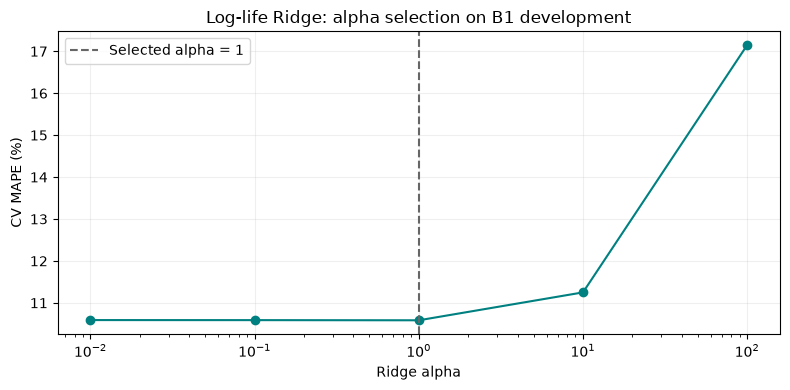

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tuning_scores['alpha'], tuning_scores['CV_MAPE_pct'], marker='o', color='teal')
ax.axvline(best_alpha, color='0.4', linestyle='--', label=f'Selected alpha = {best_alpha:g}')
ax.set(xscale='log', xlabel='Ridge alpha', ylabel='CV MAPE (%)',
       title='Log-life Ridge: alpha selection on B1 development')
ax.grid(alpha=.2)
ax.legend()
fig.tight_layout()
plt.show()

**그래프 읽기:** 낮은 점일수록 개발 CV의 상대 오차가 작습니다. 점선은 선택한 alpha입니다.
x축을 로그 눈금으로 표시한 이유는 alpha 후보가 10배 간격이기 때문입니다.
이 그래프가 오른쪽으로 갈수록 항상 좋아져야 하는 것은 아닙니다.

## 6. Validation 평가 → B1 전체 재학습 → B2 Test 평가

In [13]:
development_model = make_model(best_alpha)
development_model.fit(X_train, y_train)
valid_pred = development_model.predict(X_valid)
validation_scores = evaluate(y_valid, valid_pred, 'Validation / B1 hold-out / 로그 수명 Ridge')
validation_predictions = df_valid[['cell_uid', 'batch_id', 'policy_group', TARGET]].copy()
validation_predictions['predicted_log10'] = development_model.regressor_.predict(X_valid)
validation_predictions['predicted_cycles'] = valid_pred
validation_predictions['error_cycles'] = valid_pred - y_valid
validation_predictions['APE_pct'] = np.abs(valid_pred - y_valid) / y_valid * 100
display(validation_predictions[['cell_uid', TARGET, 'predicted_log10',
                                'predicted_cycles', 'error_cycles', 'APE_pct']].round(3))

=== Validation / B1 hold-out / 로그 수명 Ridge ===
MAPE: 7.688% | MAE: 63.18 cycles
RMSE: 72.29 cycles | R²: 0.5398


,cell_uid,cycle_life,predicted_log10,predicted_cycles,error_cycles,APE_pct
0,B1_22,891.0,2.930,850.451,-40.549,4.551
1,B1_23,1014.0,2.949,889.346,-124.654,12.293
2,B1_26,870.0,2.891,777.243,-92.757,10.662
3,B1_27,842.0,2.903,800.521,-41.479,4.926
4,B1_30,709.0,2.875,749.527,40.527,5.716
5,B1_31,876.0,2.882,762.125,-113.875,12.999
6,B1_32,731.0,2.849,705.605,-25.395,3.474
7,B1_33,757.0,2.853,712.975,-44.025,5.816
8,B1_36,704.0,2.863,729.468,25.468,3.618
9,B1_37,648.0,2.864,731.103,83.103,12.825


**코드 설명:** 선택한 alpha로 개발 36셀을 다시 학습하고, 보류한 B1의 10셀을 평가합니다.
`predict`는 복원된 사이클 수명을 반환합니다. `.regressor_.predict`는 내부 Ridge의 로그 값을
읽는 방법이며 여기서는 이해를 돕는 표에만 사용합니다.
`error_cycles = 예측 − 실제`이므로 양수는 수명을 길게 예측했다는 뜻입니다.

In [14]:
final_model = make_model(best_alpha)
final_model.fit(X_full, y_full)
assert list(final_model.regressor_.feature_names_in_) == FEATURES
test_pred = final_model.predict(X_test)
test_scores = evaluate(y_test, test_pred, 'Test / B2 / 로그 수명 Ridge')
test_predictions = df_test[['cell_uid', 'batch_id', 'policy_group', TARGET]].copy()
test_predictions['predicted_log10'] = final_model.regressor_.predict(X_test)
test_predictions['predicted_cycles'] = test_pred
test_predictions['error_cycles'] = test_pred - y_test
test_predictions['APE_pct'] = np.abs(test_pred - y_test) / y_test * 100
evaluation_metrics = pd.DataFrame([
    {'Split': 'Validation / B1 hold-out', **validation_scores},
    {'Split': 'Test / B2', **test_scores},
])
display(evaluation_metrics.round(4))
display(test_predictions[['cell_uid', TARGET, 'predicted_log10',
                         'predicted_cycles', 'error_cycles', 'APE_pct']]
        .sort_values('APE_pct', ascending=False).head(10).round(3))
print('최종 학습 셀 수:', len(y_full), '/ Test 셀 수:', len(y_test))

=== Test / B2 / 로그 수명 Ridge ===
MAPE: 34.485% | MAE: 167.00 cycles
RMSE: 179.66 cycles | R²: 0.3290


,Split,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,Validation / B1 hold-out,7.6880,63.1832,72.2876,0.5398
1,Test / B2,34.4849,167.0048,179.6612,0.3290


,cell_uid,cycle_life,predicted_log10,predicted_cycles,error_cycles,APE_pct
6,B2_6,393.0,2.854,713.835,320.835,81.637
15,B2_15,396.0,2.851,708.823,312.823,78.996
18,B2_18,449.0,2.870,740.587,291.587,64.941
2,B2_2,424.0,2.815,652.751,228.751,53.951
19,B2_19,392.0,2.772,591.154,199.154,50.805
29,B2_31,425.0,2.804,637.498,212.498,49.999
21,B2_21,408.0,2.779,601.736,193.736,47.484
11,B2_11,449.0,2.820,661.192,212.192,47.259
27,B2_29,452.0,2.821,661.975,209.975,46.455
17,B2_17,471.0,2.837,687.576,216.576,45.982


최종 학습 셀 수: 46 / Test 셀 수: 39


**코드 설명:** alpha를 바꾸지 않고 B1 전체 46셀로 새 모델을 학습한 뒤 B2를 예측합니다.
표의 모든 지표는 원래 사이클 단위에서 계산합니다. MAPE는 %, MAE·RMSE는 사이클,
R²는 단위가 없습니다. 첫 표가 최종 Valid·Test 성능이고, 다음 표는 B2에서 오차가 큰 10셀입니다.
Test 결과를 보고 alpha를 다시 고르지 않습니다.

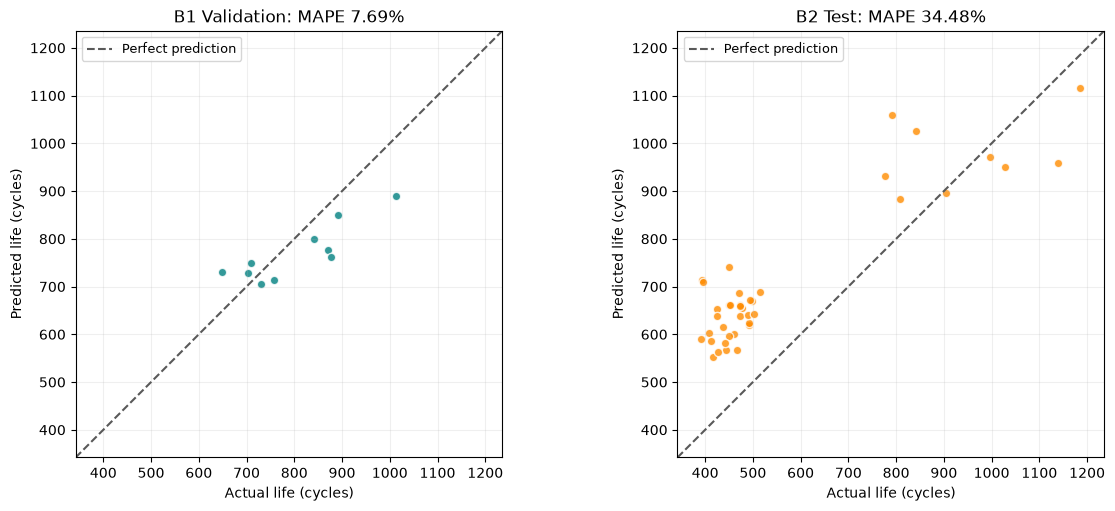

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
all_values = np.concatenate([np.asarray(y_valid), valid_pred, np.asarray(y_test), test_pred])
lower, upper = max(0, float(all_values.min()) - 50), float(all_values.max()) + 50
for ax, actual, predicted, title, scores, color in [
    (axes[0], y_valid, valid_pred, 'B1 Validation', validation_scores, 'teal'),
    (axes[1], y_test, test_pred, 'B2 Test', test_scores, 'darkorange'),
]:
    ax.scatter(actual, predicted, color=color, alpha=.8, edgecolor='white')
    ax.plot([lower, upper], [lower, upper], color='0.35', linestyle='--', label='Perfect prediction')
    ax.set(xlabel='Actual life (cycles)', ylabel='Predicted life (cycles)',
           xlim=(lower, upper), ylim=(lower, upper),
           title=f"{title}: MAPE {scores['MAPE_pct']:.2f}%")
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=.2)
    ax.legend(fontsize=9)
plt.show()

**그래프 읽기:** 점선 위에 있으면 실제보다 수명을 길게, 아래에 있으면 짧게 예측했습니다.
모든 점이 점선에 가까울수록 좋습니다. 두 그림은 같은 축 범위를 사용하며,
로그가 아니라 **복원한 사이클 수명**을 보여줍니다.
B2의 점들이 한 방향으로 벗어나면 배치 전체에 걸친 예측 편향을 점검합니다.

## 7. 보고용 Train 성능: nested CV

In [16]:
outer_splits = list(GroupKFold(n_splits=5).split(X_train, y_train, groups_train))
inner_splits_by_outer = []
outer_membership_rows, inner_membership_rows = [], []
for outer_fold, (outer_fit, outer_check) in enumerate(outer_splits, start=1):
    outer_groups = groups_train.iloc[outer_fit]
    assert set(outer_groups).isdisjoint(set(groups_train.iloc[outer_check]))
    inner_splits = list(GroupKFold(n_splits=3).split(
        X_train.iloc[outer_fit], y_train.iloc[outer_fit], outer_groups))
    inner_splits_by_outer.append(inner_splits)
    for role, indices in [('train', outer_fit), ('validation', outer_check)]:
        for position in indices:
            outer_membership_rows.append({'outer_fold': outer_fold, 'role': role,
                                         'cell_uid': df_train.iloc[position]['cell_uid'],
                                         'policy_group': groups_train.iloc[position]})
    for inner_fold, (inner_fit, inner_check) in enumerate(inner_splits, start=1):
        assert set(outer_groups.iloc[inner_fit]).isdisjoint(set(outer_groups.iloc[inner_check]))
        for role, indices in [('train', inner_fit), ('validation', inner_check)]:
            for local_position in indices:
                position = outer_fit[local_position]
                inner_membership_rows.append({'outer_fold': outer_fold, 'inner_fold': inner_fold,
                                             'role': role, 'cell_uid': df_train.iloc[position]['cell_uid'],
                                             'policy_group': groups_train.iloc[position]})
nested_outer_membership = pd.DataFrame(outer_membership_rows)
nested_inner_membership = pd.DataFrame(inner_membership_rows)
print('개발 36셀: 바깥 5-fold 평가 / 안쪽 3-fold alpha 선택 준비 완료')

개발 36셀: 바깥 5-fold 평가 / 안쪽 3-fold alpha 선택 준비 완료


**코드 설명:** alpha를 고른 CV 점수는 선택에 사용했으므로 낙관적일 수 있습니다.
성능 보고를 위해 개발 36셀에서 **바깥 5-fold / 안쪽 3-fold**를 만듭니다.
바깥 검증 폴드는 alpha 선택에도 사용하지 않습니다. 안쪽·바깥 모두 정책 그룹이 겹치지 않습니다.
여기서 만드는 폴드는 기존 `1vs2`와 같으며 Validation 10셀과 B2는 들어가지 않습니다.

In [17]:
def run_nested_cv(target_mode='log10'):
    fold_rows, prediction_frames, trial_frames = [], [], []
    for outer_fold, (outer_fit, outer_check) in enumerate(outer_splits, start=1):
        X_fit, y_fit = X_train.iloc[outer_fit], y_train.iloc[outer_fit]
        fold_alpha, _, inner_trials = select_alpha(
            X_fit, y_fit, inner_splits_by_outer[outer_fold - 1], target_mode)
        trial_frames.append(inner_trials.assign(outer_fold=outer_fold))
        model = make_model(fold_alpha, target_mode)
        model.fit(X_fit, y_fit)
        predicted = model.predict(X_train.iloc[outer_check])
        scores = evaluate(y_train.iloc[outer_check], predicted)
        fold_rows.append({'outer_fold': outer_fold, 'selected_alpha': fold_alpha,
                          'valid_cells': len(outer_check), **scores})
        frame = df_train.iloc[outer_check][['cell_uid', 'policy_group', TARGET]].copy()
        frame['outer_fold'] = outer_fold
        frame['predicted_cycles'] = predicted
        prediction_frames.append(frame)
    folds = pd.DataFrame(fold_rows)
    oof = pd.concat(prediction_frames, ignore_index=True)
    assert len(oof) == len(df_train) and oof['cell_uid'].is_unique
    assert set(oof['cell_uid']) == set(df_train['cell_uid'])
    pooled = evaluate(oof[TARGET], oof['predicted_cycles'])
    summary = {'Nested_CV_MAPE_pct': float(folds['MAPE_pct'].mean()),
               'Nested_CV_MAPE_std_pp': float(folds['MAPE_pct'].std()),
               'OOF_MAPE_pct': pooled['MAPE_pct']}
    return summary, folds, oof, pd.concat(trial_frames, ignore_index=True)

nested_summary, nested_fold_scores, nested_oof_predictions, nested_trials = run_nested_cv()
display(nested_fold_scores.round(4))
display(pd.DataFrame([nested_summary]).round(4))

,outer_fold,selected_alpha,valid_cells,MAPE_pct,MAE_cycles,RMSE_cycles,R2
0,1,0.1,7,18.0144,200.3538,267.7162,-0.9506
1,2,10.0,8,14.7047,124.7510,141.8298,0.6437
2,3,1.0,8,9.8068,76.4830,86.1314,0.3235
3,4,1.0,7,12.1131,118.8553,135.8010,-0.9065
4,5,1.0,6,9.3973,55.3007,65.1985,0.8163


,Nested_CV_MAPE_pct,Nested_CV_MAPE_std_pp,OOF_MAPE_pct
0,12.8073,3.5996,12.8714


**코드 설명:** 각 바깥 학습 데이터 안에서 alpha를 새로 선택한 후, 보류한 바깥 폴드를 예측합니다.
최종 모델의 `best_alpha`는 바꾸지 않습니다.
`Nested_CV_MAPE_pct`는 5개 바깥 폴드 MAPE의 평균이며 과제의 Train 항목에 사용합니다.
`OOF_MAPE_pct`는 개발 36셀의 보류 예측을 모두 모아 계산한 값입니다.
폴드마다 셀 수가 달라 두 값이 약간 다를 수 있습니다. 학습한 셀 자체의 오차는 Train 지표로 쓰지 않습니다.

## 8. Train / Valid / Test / GAP 결과

In [18]:
train_mape = nested_summary['Nested_CV_MAPE_pct']
valid_mape = validation_scores['MAPE_pct']
test_mape = test_scores['MAPE_pct']
day2_report = pd.DataFrame({
    '로그 수명 Ridge · 2피처': [train_mape, valid_mape, test_mape,
                               valid_mape - train_mape, test_mape - valid_mape,
                               test_mape - PAPER_TARGET_MAPE],
    '단위': ['%', '%', '%', '%p', '%p', '%p'],
    '계산·해석': [
        '개발 36셀: nested CV 바깥 5-fold MAPE 평균',
        'B1 hold-out 10셀 MAPE',
        'B1 전체 재학습 후 B2 39셀 MAPE',
        'Valid − Train; (+) 과적합 가능성 점검',
        'Test − Valid; (+) 배치간 일반화 저하 점검',
        'Test − 9.1; (+) 참고 목표보다 높은 오차',
    ],
}, index=pd.Index([
    'Train (Batch 1 CV)', 'Valid (Batch 1 Hold-out)', 'Test (Batch 2)',
    'Gap (Train-Valid)', 'Gap (Valid-Test)', 'Gap (Target-Test)',
], name='항목'))
display(day2_report.round(4))
print('모든 성능은 복원한 사이클 수명의 MAPE입니다. Target = 9.1% (참고 목표)')

,로그 수명 Ridge · 2피처,단위,계산·해석
항목,,,
Train (Batch 1 CV),12.8073,%,개발 36셀: nested CV 바깥 5-fold MAPE 평균
Valid (Batch 1 Hold-out),7.6880,%,B1 hold-out 10셀 MAPE
Test (Batch 2),34.4849,%,B1 전체 재학습 후 B2 39셀 MAPE
Gap (Train-Valid),-5.1193,%p,Valid − Train; (+) 과적합 가능성 점검
Gap (Valid-Test),26.7970,%p,Test − Valid; (+) 배치간 일반화 저하 점검
Gap (Target-Test),25.3849,%p,Test − 9.1; (+) 참고 목표보다 높은 오차


모든 성능은 복원한 사이클 수명의 MAPE입니다. Target = 9.1% (참고 목표)


**표 읽기:** 앞의 세 행은 MAPE(%)이고, 뒤의 세 행은 MAPE의 차이(%p)입니다.
Gap은 행 이름의 왼쪽에서 오른쪽으로 갈 때 **얼마나 오차가 커졌는지**를 표시합니다.
예를 들어 Valid 8%, Test 30%라면 `Gap (Valid-Test)=22%p`입니다.
양수 Gap만으로 과적합이나 특정 피처의 문제를 확정할 수는 없습니다.

로컬 B2는 `2018-02-20` 파일이며, 공식 셀 병합·수명 보정을 적용하지 않았습니다.
원논문과 데이터 분할 및 모델이 달라 9.1%는 참고 목표입니다. B1 hold-out과 B2는 이전 EDA에서
이미 확인한 데이터이므로 완전히 처음 보는 독립 데이터에서 얻은 성능으로 해석하지 않습니다.

## 9. 원수명 Ridge와 비교 — 피처와 분할은 같게 유지

In [19]:
# 비교 기준선: 기존과 같이 원래 cycle_life를 학습하는 두 피처 Ridge
raw_alpha, raw_tuning_scores, raw_tuning_trials = select_alpha(
    X_train, y_train, cv_splits, target_mode='raw')
raw_development_model = make_model(raw_alpha, target_mode='raw')
raw_development_model.fit(X_train, y_train)
raw_valid_pred = raw_development_model.predict(X_valid)
raw_valid_scores = evaluate(y_valid, raw_valid_pred)
raw_final_model = make_model(raw_alpha, target_mode='raw')
raw_final_model.fit(X_full, y_full)
raw_test_pred = raw_final_model.predict(X_test)
raw_test_scores = evaluate(y_test, raw_test_pred)
raw_nested_summary, raw_nested_folds, raw_nested_oof, raw_nested_trials = run_nested_cv('raw')

comparison = pd.DataFrame([
    {'Model': 'Ridge / raw life', 'Alpha': raw_alpha,
     'Tuning_CV_MAPE_pct': float(raw_tuning_scores['CV_MAPE_pct'].min()),
     'Train_Nested_CV_MAPE_pct': raw_nested_summary['Nested_CV_MAPE_pct'],
     'Valid_MAPE_pct': raw_valid_scores['MAPE_pct'], 'Test_MAPE_pct': raw_test_scores['MAPE_pct']},
    {'Model': 'Ridge / log10 life', 'Alpha': best_alpha,
     'Tuning_CV_MAPE_pct': float(tuning_scores['CV_MAPE_pct'].min()),
     'Train_Nested_CV_MAPE_pct': train_mape,
     'Valid_MAPE_pct': valid_mape, 'Test_MAPE_pct': test_mape},
]).set_index('Model')
display(comparison.round(4))
print(f'로그 − 원수명: Valid {valid_mape - raw_valid_scores["MAPE_pct"]:+.3f}%p, '
      f'Test {test_mape - raw_test_scores["MAPE_pct"]:+.3f}%p')

,Alpha,Tuning_CV_MAPE_pct,Train_Nested_CV_MAPE_pct,Valid_MAPE_pct,Test_MAPE_pct
Model,,,,,
Ridge / raw life,0.01,9.4155,9.7807,7.0074,30.7252
Ridge / log10 life,1.00,10.5840,12.8073,7.6880,34.4849


로그 − 원수명: Valid +0.681%p, Test +3.760%p


**코드 설명:** 두 모델 모두 **ΔQ 로그 분산 + SOC** 두 피처를 사용합니다.
학습 정답만 원수명 / 로그 수명으로 바꾸고, 각 모델의 alpha는 같은 B1 개발 CV에서 따로 선택합니다.
따라서 이 표는 같은 피처·셀·폴드·튜닝 절차에서 **타깃 변환을 포함한 모델링 방법**을 비교합니다.
alpha가 달라졌다면 타깃만 바꾸고 alpha까지 고정한 실험과는 구분합니다.

`로그 − 원수명`이 음수면 로그 모델의 오차가 더 작습니다.
이 노트북의 주 모델은 요청한 로그 수명 Ridge로 고정했으며, Test 점수를 이용해 모델을 바꾸지 않습니다.

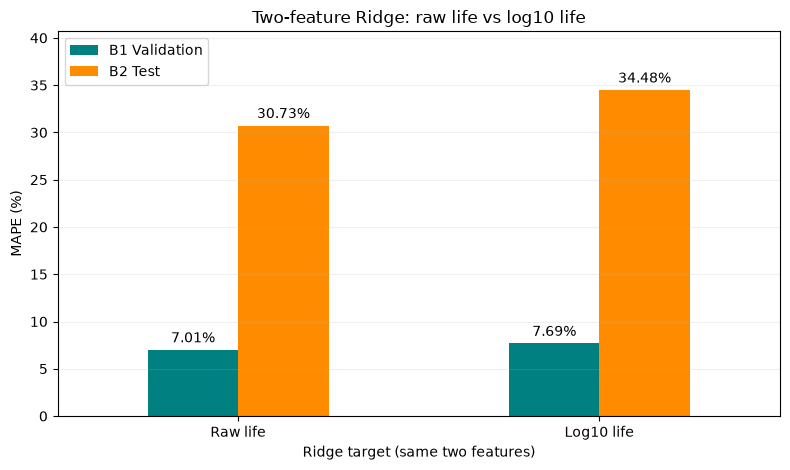

In [20]:
plot_data = comparison[['Valid_MAPE_pct', 'Test_MAPE_pct']].copy()
plot_data.index = ['Raw life', 'Log10 life']
ax = plot_data.plot.bar(figsize=(8, 4.8), rot=0, color=['teal', 'darkorange'])
ax.set(xlabel='Ridge target (same two features)', ylabel='MAPE (%)',
       title='Two-feature Ridge: raw life vs log10 life')
ax.legend(['B1 Validation', 'B2 Test'], loc='upper left')
ax.grid(axis='y', alpha=.2)
ax.set_ylim(0, plot_data.to_numpy().max() * 1.18)
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f%%', padding=3)
ax.figure.tight_layout()
plt.show()

**그래프 읽기:** 같은 색끼리 원수명 모델과 로그 모델을 비교합니다.
청록색은 Valid, 주황색은 Test입니다. 로그 학습이 Valid에서 좋아져도 Test에서도 반드시
좋아지는 것은 아닙니다. 실제 출력된 숫자로 확인하세요.

## 10. 로그 모델의 오차와 계수 이해

In [21]:
b1_min_life = float(y_full.min())
test_diagnostics = test_predictions.copy()
test_diagnostics['life_group'] = np.where(
    test_diagnostics[TARGET] < b1_min_life, 'Below B1 minimum life', 'At or above B1 minimum life')
test_diagnostics['abs_error_cycles'] = test_diagnostics['error_cycles'].abs()
test_diagnostics['overpredicted'] = test_diagnostics['error_cycles'] > 0
diagnostic_summary = test_diagnostics.groupby('life_group').agg(
    cells=('cell_uid', 'size'), MAPE_pct=('APE_pct', 'mean'),
    MAE_cycles=('abs_error_cycles', 'mean'), mean_error_cycles=('error_cycles', 'mean'),
    overpredicted_cells=('overpredicted', 'sum'))
display(diagnostic_summary.round(3))
print(f'B1 최저 수명: {b1_min_life:g} 사이클')
print(f'B2 과대예측: {int(test_diagnostics["overpredicted"].sum())}/{len(test_diagnostics)}개')
print('첫 피처가 B1 관찰 범위 안인 B2 셀:',
      int(X_test[FEATURES[0]].between(X_full[FEATURES[0]].min(), X_full[FEATURES[0]].max()).sum()),
      '/', len(X_test))

,cells,MAPE_pct,MAE_cycles,mean_error_cycles,overpredicted_cells
life_group,,,,,
At or above B1 minimum life,9,13.086,116.108,35.200,4
Below B1 minimum life,30,40.905,182.274,182.274,30


B1 최저 수명: 534 사이클
B2 과대예측: 34/39개
첫 피처가 B1 관찰 범위 안인 B2 셀: 28 / 39


**코드 설명:** Test를 B1 최저 수명보다 짧은 집단과 나머지로 나눠 MAPE·MAE·평균 잔차를 봅니다.
이는 **평가 후 원인을 살피는 분석**이며 B2를 정제하거나 모델을 다시 고르는 데 사용하지 않습니다.
평균 잔차가 양수이고 과대예측 셀이 많으면 수명을 전반적으로 길게 예측한 것입니다.

짧은 수명은 같은 사이클 오차에도 MAPE가 커집니다. MAE도 함께 확인하세요.
수명이 B1 범위 아래에 있다는 사실과 피처가 B1 범위 밖이라는 사실은 다릅니다.
로그 변환은 배치 차이를 자동으로 없애지 않습니다.

In [22]:
fitted_pipeline = final_model.regressor_
fitted_ridge = fitted_pipeline.named_steps['ridge']
fitted_scaler = fitted_pipeline.named_steps['scaler']
coefficient_table = pd.DataFrame({
    'feature': FEATURES,
    'B1_scaler_mean': fitted_scaler.mean_, 'B1_scaler_scale': fitted_scaler.scale_,
    'log10_coefficient': fitted_ridge.coef_,
    'life_multiplier_per_1std': exp10(fitted_ridge.coef_),
})
display(coefficient_table.round(5))
print(f'log10(예측 수명) = {fitted_ridge.intercept_:.6f} '
      f'{fitted_ridge.coef_[0]:+.6f} × 표준화 ΔQ로그 '
      f'{fitted_ridge.coef_[1]:+.6f} × 표준화 SOC')

,feature,B1_scaler_mean,B1_scaler_scale,log10_coefficient,life_multiplier_per_1std
0,log10_delta_q_var,-3.92343,0.37414,-0.08303,0.82598
1,SOC_switch_pct,51.52174,19.24865,-0.01097,0.97506


log10(예측 수명) = 2.916675 -0.083033 × 표준화 ΔQ로그 -0.010968 × 표준화 SOC


**코드 설명:** Ridge는 표준화된 두 피처의 선형 결합으로 로그 수명을 예측합니다.
다른 피처를 고정한 채 한 피처가 학습 데이터의 표준편차 1만큼 커지면,
예측 수명은 `10 ** 해당 계수`배가 됩니다. 예를 들어 계수 −0.1이면 약 0.794배입니다.
표준화 기준은 최종 모델을 학습한 B1 전체에서 계산한 값입니다.
이 계수는 모델이 학습한 관계이며 충전 정책의 인과 효과를 뜻하지 않습니다.

## 11. 선택 사항: 결과와 모델 저장

In [23]:
config = {
    'features': FEATURES, 'target': TARGET, 'target_transform': 'log10',
    'inverse_transform': '10 ** predicted_log10', 'model': 'Ridge',
    'selected_alpha': best_alpha, 'alpha_candidates': ALPHAS, 'seed': SEED,
    'selection_metric': 'cycle-space mean fold MAPE (%)',
    'B1_development_cells': len(y_train), 'B1_holdout_cells': len(y_valid),
    'final_fit_B1_cells': len(y_full), 'B2_test_cells': len(y_test),
    'tuning_group_folds': 3, 'reporting_outer_group_folds': 5, 'reporting_inner_group_folds': 3,
    'validation_or_test_used_for_selection': False, 'holdout_and_B2_previously_viewed_in_EDA': True,
    'official_cell_merge_applied': False, 'paper_target_mape_percent': PAPER_TARGET_MAPE,
    'cohort_note': 'Raw local B1; B2 is 2018-02-20; 9.1% is a reference target.',
    'input_mode': 'original MAT only',
    'extracted_input_sha256': hashlib.sha256(
        data.to_csv(index=False, float_format='%.17g').encode()).hexdigest(),
    'raw_source_files': {b: {'name': p.name, 'size_bytes': p.stat().st_size}
                         for b, p in BATCH_FILES.items()},
    'raw_reference_selected_alpha': raw_alpha, 'save_outputs': SAVE_OUTPUTS,
}
tables_to_save = {
    'cohort_audit.csv': cohort_audit, 'excluded_cells.csv': excluded_cells,
    'split_membership.csv': split_membership, 'tuning_cv_scores.csv': tuning_scores,
    'tuning_cv_trials.csv': tuning_trials, 'tuning_fold_membership.csv': cv_fold_membership,
    'validation_predictions.csv': validation_predictions, 'test_predictions.csv': test_predictions,
    'evaluation_metrics.csv': evaluation_metrics, 'nested_fold_scores.csv': nested_fold_scores,
    'nested_oof_predictions.csv': nested_oof_predictions, 'nested_inner_trials.csv': nested_trials,
    'nested_outer_membership.csv': nested_outer_membership,
    'nested_inner_membership.csv': nested_inner_membership,
    'day2_report.csv': day2_report.reset_index(), 'raw_vs_loglife_comparison.csv': comparison.reset_index(),
    'test_diagnostics.csv': diagnostic_summary.reset_index(), 'coefficients.csv': coefficient_table,
}
if SAVE_OUTPUTS:
    OUT.mkdir(parents=True, exist_ok=True)
    for name, table in tables_to_save.items():
        table.to_csv(OUT / name, index=False, encoding='utf-8-sig')
    joblib.dump(final_model, OUT / 'ridge_loglife_2features.joblib')
    (OUT / 'model_config.json').write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding='utf-8')
    print('저장 완료:', OUT)
else:
    print('실행 결과는 노트북에서 확인합니다. 별도 파일 저장은 꺼져 있습니다.')

실행 결과는 노트북에서 확인합니다. 별도 파일 저장은 꺼져 있습니다.


**코드 설명:** 기본값에서는 추가 CSV·모델 파일을 만들지 않습니다.
원하면 1절에서 `SAVE_OUTPUTS=True`로 바꾸고 전체 실행하면 이 노트북 전용 폴더에 저장합니다.
저장된 모델에는 전처리와 타깃 변환·복원이 함께 들어 있어, 불러온 뒤 `predict`하면
사이클 단위의 수명을 얻습니다. 설정에는 사용한 두 피처와 선택 alpha, 데이터 분할을 기록합니다.

다시 결과를 읽을 때는 **8절의 과제 6행 표 → 9절의 원수명·로그 수명 비교 → 10절의 잔차** 순서로 봅니다.